# Naruto Hand Sign — GNN Training
Trains a **Graph Attention Network (GAT)** on MediaPipe hand landmark graphs.

- **Nodes**: 42 landmarks (21 per hand × 2 hands), each with (x, y, z) features (wrist-relative, scale-invariant)
- **Edges**: 21 bone connections per hand + 1 inter-wrist edge (86 bidirectional edges total)
- **Architecture**: Linear projection → 4 × GATBlock (attention + residual + BatchNorm) → Mean+Max pooling → MLP classifier
- **Input**: `data/landmarks_gnn.csv` (collected via `collect_landmarks.py`)

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch_geometric.data import Data, Dataset
from torch_geometric.loader import DataLoader
from torch_geometric.nn import GATConv, global_mean_pool, global_max_pool
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
import os
import json
import matplotlib.pyplot as plt

C:\Users\nguye\AppData\Roaming\Python\Python313\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Configuration

In [2]:
CSV_FILE = 'data/landmarks_gnn.csv'
MODEL_FILE = 'model/gnn.pt'
LABEL_MAP_FILE = 'model/label_map_gnn.json'
os.makedirs('model', exist_ok=True)

EPOCHS = 100
PATIENCE = 10
LR = 1e-3
BATCH_SIZE = 32
NUM_NODES = 42  # 21 per hand x 2 hands

## Graph Structure with Hand Edges

In [3]:
# MediaPipe hand bone connections per hand
_EDGES_ONE = [
    (0,1),(1,2),(2,3),(3,4),
    (0,5),(5,6),(6,7),(7,8),
    (5,9),(9,10),(10,11),(11,12),
    (9,13),(13,14),(14,15),(15,16),
    (13,17),(17,18),(18,19),(19,20),(0,17),
]

# Hand0 edges + Hand1 edges (offset by 21) + inter-wrist edge
EDGES = _EDGES_ONE + [(a+21, b+21) for a,b in _EDGES_ONE] + [(0, 21)]

# Bidirectional edge_index
_src = [a for a,b in EDGES] + [b for a,b in EDGES]
_dst = [b for a,b in EDGES] + [a for a,b in EDGES]
EDGE_INDEX = torch.tensor([_src, _dst], dtype=torch.long)
print(f"Nodes: {NUM_NODES}  |  Edges (bidirectional): {EDGE_INDEX.shape[1]}")

Nodes: 42  |  Edges (bidirectional): 86


## GAT Model (Graph Attention Network + Residual + BN)

In [4]:
class GATBlock(nn.Module):
    def __init__(self, in_ch, out_ch, heads=4):
        super().__init__()
        self.gat = GATConv(in_ch, out_ch // heads, heads=heads, dropout=0.3)
        self.bn  = nn.BatchNorm1d(out_ch)
        self.proj = nn.Linear(in_ch, out_ch) if in_ch != out_ch else nn.Identity()

    def forward(self, x, edge_index):
        return torch.relu(self.bn(self.gat(x, edge_index)) + self.proj(x))


class GAT(nn.Module):
    def __init__(self, in_channels, hidden_channels, num_classes, num_layers=4):
        super().__init__()
        self.input_proj = nn.Linear(in_channels, hidden_channels)
        self.blocks = nn.ModuleList([
            GATBlock(hidden_channels, hidden_channels) for _ in range(num_layers)
        ])
        self.classifier = nn.Sequential(
            nn.Linear(hidden_channels * 2, 256),
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, num_classes),
        )

    def forward(self, x, edge_index, batch):
        x = torch.relu(self.input_proj(x))
        for block in self.blocks:
            x = block(x, edge_index)
        # Concat mean + max pooling for richer graph representation
        x = torch.cat([global_mean_pool(x, batch), global_max_pool(x, batch)], dim=1)
        return self.classifier(x)

## Dataset

In [5]:
class LandmarkGraphDataset(Dataset):
    def __init__(self, node_features, labels):
        super().__init__()
        self.node_features = node_features
        self.labels = labels

    def len(self):
        return len(self.labels)

    def get(self, idx):
        x = torch.tensor(self.node_features[idx], dtype=torch.float)
        y = torch.tensor(self.labels[idx], dtype=torch.long)
        return Data(x=x, edge_index=EDGE_INDEX.clone(), y=y)


# CSV has no header: 126 feature cols + 1 label col
df = pd.read_csv(CSV_FILE, header=None)
df.columns = [f'n{i}_{c}' for i in range(NUM_NODES) for c in ['x', 'y', 'z']] + ['label']
print(f"Loaded {len(df)} samples")

feature_cols = [c for c in df.columns if c != 'label']
X = df[feature_cols].values.astype(np.float32).reshape(-1, NUM_NODES, 3)

le = LabelEncoder()
y = le.fit_transform(df['label'].values)
num_classes = len(le.classes_)
print(f"Classes ({num_classes}): {list(le.classes_)}")

label_map = {i: name for i, name in enumerate(le.classes_)}
with open(LABEL_MAP_FILE, 'w') as f:
    json.dump(label_map, f, indent=2)

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.15, random_state=42, stratify=y
)

train_ds = LandmarkGraphDataset(X_train, y_train)
val_ds   = LandmarkGraphDataset(X_val,   y_val)
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}  |  {len(X_train)} train / {len(X_val)} val")

Loaded 1040 samples
Classes (12): ['Bird', 'Boar', 'Dog', 'Dragon', 'Hare', 'Horse', 'Monkey', 'Ox', 'Ram', 'Rat', 'Snake', 'Tiger']
Device: cpu  |  884 train / 156 val


## Training

In [6]:
model = GAT(in_channels=3, hidden_channels=128, num_classes=num_classes, num_layers=4).to(device)
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
optimizer = optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-3)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS, eta_min=1e-5)

best_val_acc = 0.0
patience_counter = 0
train_accs = []
val_accs = []

for epoch in range(1, EPOCHS + 1):
    # ── Train ──
    model.train()
    total_loss = 0
    correct_train = total_train = 0
    for batch in train_loader:
        batch = batch.to(device)
        optimizer.zero_grad()
        out = model(batch.x, batch.edge_index, batch.batch)
        loss = criterion(out, batch.y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
        correct_train += (out.detach().argmax(dim=1) == batch.y).sum().item()
        total_train += len(batch.y)
    scheduler.step()
    train_acc = correct_train / total_train

    # ── Validate ──
    model.eval()
    correct = total = 0
    with torch.no_grad():
        for batch in val_loader:
            batch = batch.to(device)
            preds = model(batch.x, batch.edge_index, batch.batch).argmax(dim=1)
            correct += (preds == batch.y).sum().item()
            total += len(batch.y)
    val_acc = correct / total if total > 0 else 0.0

    train_accs.append(train_acc)
    val_accs.append(val_acc)

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        patience_counter = 0
        torch.save(model.state_dict(), MODEL_FILE)
    else:
        patience_counter += 1

    print(f"Epoch {epoch:3d}/{EPOCHS} | loss: {total_loss/len(train_loader):.4f} | train acc: {train_acc:.3f} | val acc: {val_acc:.3f} | patience: {patience_counter}/{PATIENCE}")

    if patience_counter >= PATIENCE:
        print(f"Early stopping at epoch {epoch}.")
        break

print(f"\nBest val accuracy: {best_val_acc:.3f}")
print(f"Model saved to {MODEL_FILE}")

Epoch   1/100 | loss: 2.1670 | train acc: 0.253 | val acc: 0.385 | patience: 0/10
Epoch   2/100 | loss: 1.5762 | train acc: 0.519 | val acc: 0.763 | patience: 0/10
Epoch   3/100 | loss: 1.2331 | train acc: 0.707 | val acc: 0.904 | patience: 0/10
Epoch   4/100 | loss: 0.9847 | train acc: 0.857 | val acc: 0.929 | patience: 0/10
Epoch   5/100 | loss: 0.9100 | train acc: 0.891 | val acc: 0.949 | patience: 0/10
Epoch   6/100 | loss: 0.8507 | train acc: 0.917 | val acc: 0.929 | patience: 1/10
Epoch   7/100 | loss: 0.8052 | train acc: 0.931 | val acc: 0.955 | patience: 0/10
Epoch   8/100 | loss: 0.7500 | train acc: 0.956 | val acc: 0.955 | patience: 1/10
Epoch   9/100 | loss: 0.7475 | train acc: 0.958 | val acc: 0.974 | patience: 0/10
Epoch  10/100 | loss: 0.7229 | train acc: 0.967 | val acc: 0.987 | patience: 0/10
Epoch  11/100 | loss: 0.7084 | train acc: 0.975 | val acc: 0.987 | patience: 1/10
Epoch  12/100 | loss: 0.6941 | train acc: 0.975 | val acc: 0.981 | patience: 2/10
Epoch  13/100 | 

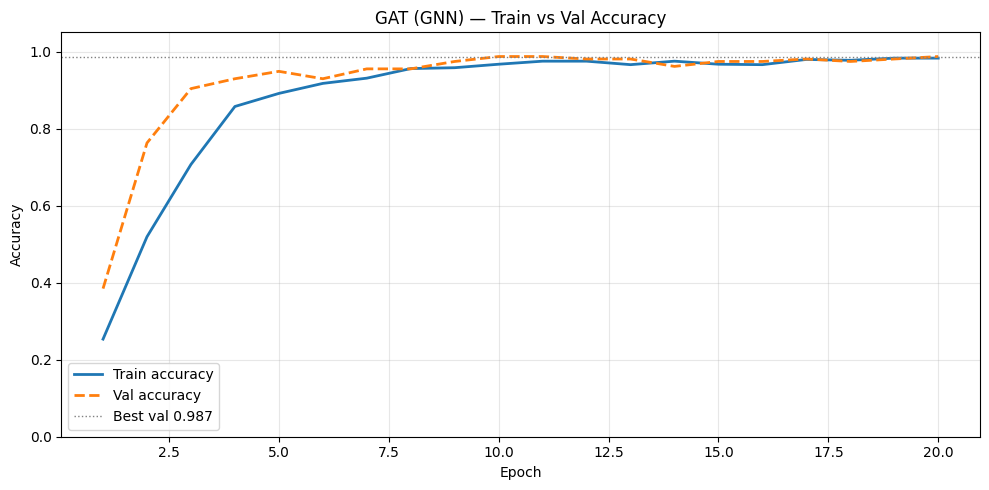

Saved to model/gnn_acc_curve.png


In [7]:
epochs = range(1, len(train_accs) + 1)

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(epochs, train_accs, label='Train accuracy', linewidth=2)
ax.plot(epochs, val_accs,   label='Val accuracy',   linewidth=2, linestyle='--')
ax.axhline(best_val_acc, color='gray', linestyle=':', linewidth=1, label=f'Best val {best_val_acc:.3f}')
ax.set_xlabel('Epoch')
ax.set_ylabel('Accuracy')
ax.set_title('GAT (GNN) — Train vs Val Accuracy')
ax.legend()
ax.set_ylim(0, 1.05)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('model/gnn_acc_curve.png', dpi=150)
plt.show()
print("Saved to model/gnn_acc_curve.png")